# Gender-focused analyses

This notebook measures how declared and activation-steered gender profiles affect OpinionQA responses, with particular attention to questions explicitly related to gender.

In [8]:
import ast, json, re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'results' / 'demo_full.csv').is_file() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the repository root.')

REPO = find_repo_root()
DEMO_PATH = REPO / 'results' / 'demo_full.csv'
OQA_PATH = REPO / 'data' / 'political_questions' / 'OpinionQA' / 'opinionqa.csv'
QDICT_PATH = REPO / 'data' / 'political_questions' / 'OpinionQA' / 'refined_qkey_dict.json'
for path in (DEMO_PATH, OQA_PATH, QDICT_PATH):
    if not path.is_file(): raise FileNotFoundError(path)
print('Repository root:', REPO)

with open(QDICT_PATH, encoding='utf-8') as stream:
    question_records = json.load(stream)
ordinals, question_text = {}, {}
for qkey, record in question_records.items():
    options = [option for option in record['options'] if option != 'Refused']
    ordinals[qkey] = np.asarray(record.get('ordinal', range(1, len(options) + 1)), float)
    question_text[qkey] = record.get('original_qbody', record.get('refined_qbody', ''))

def normalize(values):
    values = np.asarray(values, float); total = values.sum()
    return values / total if total > 0 else values
def align(values, size):
    values = np.asarray(values, float)
    return normalize(values[:size] if len(values) > size else values)
def wasserstein_ordinal(left, right, ordinal):
    size = len(ordinal); left, right = align(left, size), align(right, size)
    order = np.argsort(ordinal, kind='stable'); positions = ordinal[order]
    gap = np.abs(np.cumsum(left[order]) - np.cumsum(right[order]))
    return float(np.sum(gap[:-1] * np.diff(positions)))

demo = pd.read_csv(DEMO_PATH)
demo['dist'] = demo['response_distribution'].apply(json.loads)
gender_results = demo[demo['attribute'].eq('gender')].copy()
human_gender = {}
for _, row in pd.read_csv(OQA_PATH).iterrows():
    if row['attribute'] == 'SEX':
        human_gender[(row['qkey'], row['group'])] = np.asarray(ast.literal_eval(row['responses']), float)
print('Gender experiment rows:', len(gender_results))


Repository root: C:\Users\mario\OneDrive - csr.ufmg.br\Documents\GitHub\internal_LLM_bias
Gender experiment rows: 7904


## 1. Identify gender-related questions

A word-boundary regular expression selects questions that explicitly mention gender-related concepts.

In [9]:
GENDER_PATTERN = re.compile(
    r'\b(wom[ae]n|m[ae]n|female|male|gender|girl|boy|mother|father|wife|husband'
    r'|maternal|paternal|feminis[mt]|masculin\w*|feminin\w*|sexism|sexist)\b', re.I
)
gender_question_keys = {qkey for qkey, text in question_text.items() if GENDER_PATTERN.search(text or '')}
gender_results['gender_question'] = gender_results['qkey'].isin(gender_question_keys)
print(f'{len(gender_question_keys)} gender-related questions out of {len(question_text)} total questions')
for qkey in sorted(gender_question_keys)[:8]: print(f'- {qkey}: {question_text[qkey][:100]}')


80 gender-related questions out of 494 total questions
- BETTERBIZ1F2D_W36: In general, do you think [men or women] in TOP EXECUTIVE BUSINESS POSITIONS are better at each of th
- BETTERBIZ1F2E_W36: In general, do you think [men or women] in TOP EXECUTIVE BUSINESS POSITIONS are better at each of th
- BETTERBIZ1F2H_W36: In general, do you think [men or women] in TOP EXECUTIVE BUSINESS POSITIONS are better at each of th
- BETTERBIZ2F2C_W36: In general, do you think [men or women] would do a better job running each of the following types of
- BETTERBIZ2F2E_W36: In general, do you think [men or women] would do a better job running each of the following types of
- BETTERBIZ2F2F_W36: In general, do you think [men or women] would do a better job running each of the following types of
- BETTERPOL1F1B_W36: In general, do you think [men or women] in HIGH POLITICAL OFFICES are better at each of the followin
- BETTERPOL1F1E_W36: In general, do you think [men or women] in HIGH POLITICAL OFFICES are 

## 2. Male–female separation by question type

For each condition, the model gap is the ordinal Wasserstein distance between male and female response distributions. Other questions provide a baseline for assessing topic sensitivity.

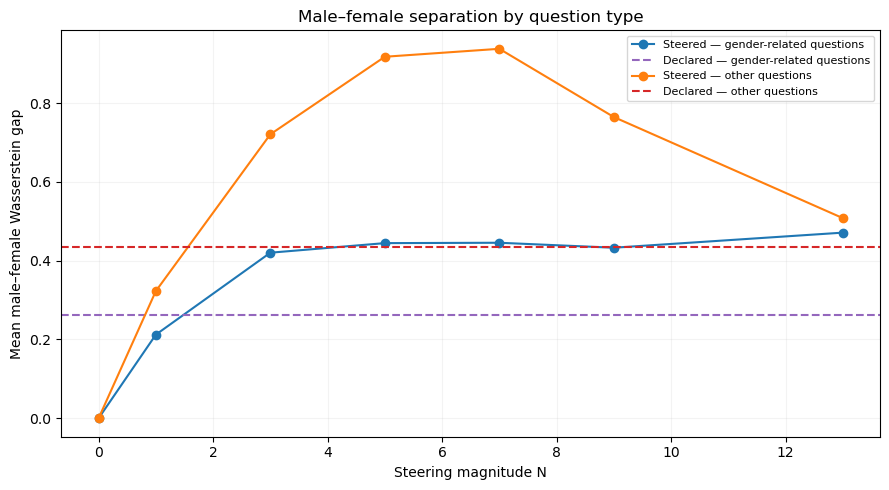

In [10]:
def male_female_gap(group):
    distributions = {row.class_label: row.dist for row in group.itertuples()}
    qkey = group.iloc[0]['qkey']
    if {'male', 'female'} <= distributions.keys() and qkey in ordinals:
        return wasserstein_ordinal(distributions['male'], distributions['female'], ordinals[qkey])
    return np.nan

records = []
for (qkey, channel, magnitude), group in gender_results.groupby(['qkey','channel','magnitude'], dropna=False):
    records.append((qkey, channel, magnitude, qkey in gender_question_keys, male_female_gap(group)))
gap = pd.DataFrame(records, columns=['qkey','channel','magnitude','gender_question','gap']).dropna(subset=['gap'])

styles = {True: ('gender-related questions','tab:blue','tab:purple'), False: ('other questions','tab:orange','tab:red')}
fig, ax = plt.subplots(figsize=(9,5))
for flag, (label, steered_color, declared_color) in styles.items():
    subset = gap[gap['gender_question'].eq(flag)]
    steered = subset[subset['channel'].eq('steered')].groupby('magnitude')['gap'].mean()
    declared = subset[subset['channel'].eq('declared')]['gap'].mean()
    ax.plot(steered.index, steered.values, marker='o', color=steered_color, label=f'Steered — {label}')
    ax.axhline(declared, ls='--', color=declared_color, label=f'Declared — {label}')
ax.set(xlabel='Steering magnitude N', ylabel='Mean male–female Wasserstein gap', title='Male–female separation by question type')
ax.grid(alpha=.15); ax.legend(fontsize=8); plt.tight_layout(); plt.show()


## 3. Distance to the matching human gender group

Lower values indicate closer agreement with the corresponding OpinionQA gender group. Only gender-related questions are included.

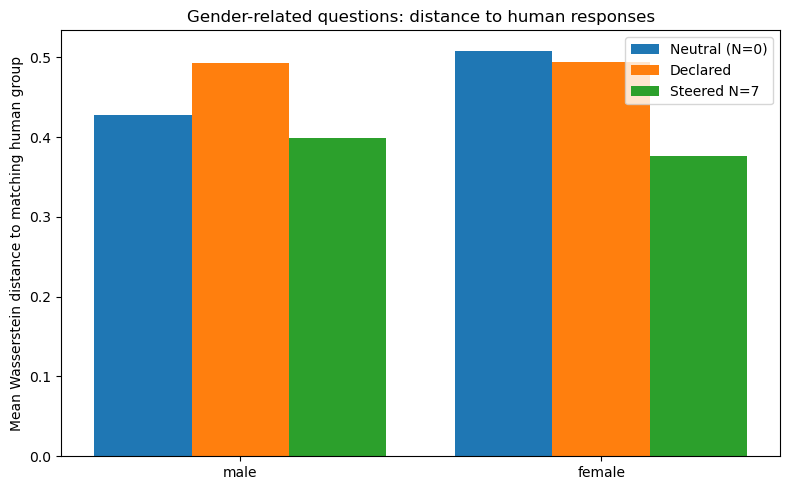

channel   magnitude  class 
declared  NaN        female    0.494
                     male      0.493
steered   0.0        female    0.508
                     male      0.428
          1.0        female    0.521
                     male      0.423
          3.0        female    0.498
                     male      0.398
          5.0        female    0.420
                     male      0.393
          7.0        female    0.376
                     male      0.399
          9.0        female    0.388
                     male      0.353
          13.0       female    0.445
                     male      0.280
Name: distance, dtype: float64

In [11]:
def distance_to_human(group, model_class, human_group):
    row = group[group['class_label'].eq(model_class)]; qkey = group.iloc[0]['qkey']; key = (qkey,human_group)
    if len(row) and key in human_gender and qkey in ordinals and len(human_gender[key]) == len(ordinals[qkey]):
        return wasserstein_ordinal(row.iloc[0]['dist'], human_gender[key], ordinals[qkey])
    return np.nan

records=[]; selected=gender_results[gender_results['gender_question']]
for (_,channel,magnitude), group in selected.groupby(['qkey','channel','magnitude'],dropna=False):
    for model_class,human_group in [('male','Male'),('female','Female')]:
        value=distance_to_human(group,model_class,human_group)
        if not np.isnan(value): records.append((model_class,channel,magnitude,value))
distance=pd.DataFrame(records,columns=['class','channel','magnitude','distance'])
labels=['male','female']; x=np.arange(2); width=.27
neutral=[distance[(distance['class']==c)&(distance.channel=='steered')&(distance.magnitude==0)].distance.mean() for c in labels]
declared=[distance[(distance['class']==c)&(distance.channel=='declared')].distance.mean() for c in labels]
steered_n7=[distance[(distance['class']==c)&(distance.channel=='steered')&(distance.magnitude==7)].distance.mean() for c in labels]
fig,ax=plt.subplots(figsize=(8,5)); ax.bar(x-width,neutral,width,label='Neutral (N=0)'); ax.bar(x,declared,width,label='Declared'); ax.bar(x+width,steered_n7,width,label='Steered N=7')
ax.set_xticks(x,labels); ax.set_ylabel('Mean Wasserstein distance to matching human group'); ax.set_title('Gender-related questions: distance to human responses'); ax.legend(); plt.tight_layout(); plt.show()
distance.groupby(['channel','magnitude','class'],dropna=False).distance.mean().round(3)


## 4. Gender-profile distance on questions not related to gender

This analysis provides a non-gender-topic baseline for the preceding gender-focused results. It uses the same question classification and human gender distributions defined above.

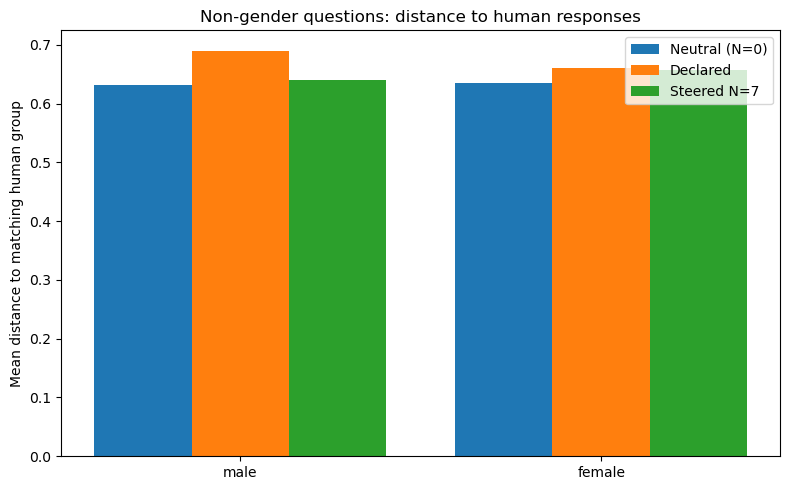

mean  median    std  count
channel  magnitude class                              
declared NaN       female  0.661   0.589  0.445    414
                   male    0.690   0.627  0.423    413
steered  0.0       female  0.635   0.585  0.396    414
                   male    0.632   0.587  0.386    413
         1.0       female  0.672   0.621  0.415    414
                   male    0.627   0.570  0.386    413
         3.0       female  0.756   0.686  0.464    414
                   male    0.611   0.558  0.391    413
         5.0       female  0.755   0.684  0.477    414
                   male    0.609   0.526  0.416    413
         7.0       female  0.656   0.539  0.440    414
                   male    0.640   0.558  0.426    413
         9.0       female  0.549   0.468  0.391    414
                   male    0.587   0.522  0.385    413
         13.0      female  0.463   0.390  0.340    414
                   male    0.488   0.445  0.284    413

In [12]:
gender_demo = gender_results[~gender_results['gender_question']].copy()
records=[]
for (qkey,channel,magnitude),group in gender_demo.groupby(['qkey','channel','magnitude'],dropna=False):
    for model_class,human_group in [('male','Male'),('female','Female')]:
        row=group[group.class_label.eq(model_class)]; key=(qkey,human_group)
        if len(row) and key in human_gender and qkey in ordinals and len(human_gender[key])==len(ordinals[qkey]): records.append((model_class,channel,magnitude,wasserstein_ordinal(row.iloc[0].dist,human_gender[key],ordinals[qkey])))
non_gender_distance=pd.DataFrame(records,columns=['class','channel','magnitude','distance']); labels=['male','female']; x=np.arange(2); width=.27
neutral_values=[non_gender_distance[(non_gender_distance['class']==c)&(non_gender_distance.channel=='steered')&(non_gender_distance.magnitude==0)].distance.mean() for c in labels]; declared_values=[non_gender_distance[(non_gender_distance['class']==c)&(non_gender_distance.channel=='declared')].distance.mean() for c in labels]; n7_values=[non_gender_distance[(non_gender_distance['class']==c)&(non_gender_distance.channel=='steered')&(non_gender_distance.magnitude==7)].distance.mean() for c in labels]
fig,ax=plt.subplots(figsize=(8,5)); ax.bar(x-width,neutral_values,width,label='Neutral (N=0)'); ax.bar(x,declared_values,width,label='Declared'); ax.bar(x+width,n7_values,width,label='Steered N=7'); ax.set_xticks(x,labels); ax.set(ylabel='Mean distance to matching human group',title='Non-gender questions: distance to human responses'); ax.legend(); plt.tight_layout(); plt.show()
non_gender_distance.groupby(['channel','magnitude','class'],dropna=False).distance.agg(['mean','median','std','count']).round(3)
